## Goal

This notebook is a local smoke test for the Freqtrade backtesting runtime. It checks the project model first, then checks Docker/Freqtrade, downloads a small historical candle range, and runs one baseline backtest.

Run it manually from Jupyter after `uv sync --dev`. The project Quarto site does not execute notebooks during publishing.

## What counts as success

The backtester is working when all of these are true:

- Python can import and run `SmaMomentumModel`.
- Docker CLI and Docker Compose are available.
- `trading/freqtrade/user_data/config.json` exists and is valid JSON.
- Freqtrade can download OHLCV candles for the configured pairs.
- Freqtrade can run `TimeAnalysisSmaStrategy` and create files in `user_data/backtest_results/`.

> This test proves runtime wiring, not strategy profitability.

In [17]:
from __future__ import annotations

import json
import shutil
import subprocess
import sys
from pathlib import Path

import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    msg = "Could not find project root with pyproject.toml"
    raise FileNotFoundError(msg)


PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"
FREQTRADE_DIR = PROJECT_ROOT / "trading" / "freqtrade"
CONFIG_EXAMPLE = FREQTRADE_DIR / "user_data" / "config.example.json"
CONFIG = FREQTRADE_DIR / "user_data" / "config.json"
BACKTEST_RESULTS = FREQTRADE_DIR / "user_data" / "backtest_results"

STRATEGY = "TimeAnalysisSmaStrategy"
TIMEFRAME = "5m"
TIMERANGE = "20250101-20250201"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

PROJECT_ROOT

WindowsPath('C:/WorkPrograms/TimeAnalysis')

## 1. Check the project model

Before running Freqtrade, check that the pure Python model works. This keeps model bugs separate from Docker or exchange-data problems.

In [18]:
from time_analysis.models.simple_momentum import (
    ENTRY_SIGNAL_COLUMN,
    EXIT_SIGNAL_COLUMN,
    SmaMomentumModel,
)

candles = pd.DataFrame(
    {"close": [3.0, 3.0, 3.0, 4.0, 5.0, 6.0, 5.0, 4.0, 3.0, 2.0, 3.0, 4.0]}
)
signals = SmaMomentumModel(fast_window=2, slow_window=3).predict(candles)

assert signals[ENTRY_SIGNAL_COLUMN].sum() == 2
assert signals[EXIT_SIGNAL_COLUMN].sum() == 1

signals.tail(8)

,close,sma_fast,sma_slow,sma_momentum_score,long_entry_signal,long_exit_signal
4,5.0,4.5,4.000000,0.125000,False,False
5,6.0,5.5,5.000000,0.100000,False,False
6,5.0,5.5,5.333333,0.031250,False,False
7,4.0,4.5,5.000000,-0.100000,False,True
8,3.0,3.5,4.000000,-0.125000,False,False
9,2.0,2.5,3.000000,-0.166667,False,False
10,3.0,2.5,2.666667,-0.062500,False,False
11,4.0,3.5,3.000000,0.166667,True,False


## 2. Check local Freqtrade files

The real runtime uses `config.json`. It is ignored by git because it may later contain private settings. If it does not exist, this notebook creates it from `config.example.json`.

In [19]:
if not CONFIG.exists():
    CONFIG.write_text(CONFIG_EXAMPLE.read_text(encoding="utf-8"), encoding="utf-8")

config = json.loads(CONFIG.read_text(encoding="utf-8"))

assert config["dry_run"] is True
assert config["exchange"]["pair_whitelist"]
assert (FREQTRADE_DIR / "docker-compose.yml").exists()
assert (FREQTRADE_DIR / "user_data" / "strategies" / "time_analysis_sma_strategy.py").exists()

{
    "exchange": config["exchange"]["name"],
    "pairs": config["exchange"]["pair_whitelist"],
    "dry_run": config["dry_run"],
    "config": str(CONFIG),
}

{'exchange': 'bybit',
 'pairs': ['BTC/USDT', 'ETH/USDT'],
 'dry_run': True,
 'config': 'C:\\WorkPrograms\\TimeAnalysis\\trading\\freqtrade\\user_data\\config.json'}

## 3. Command runner

The next helper runs shell commands and prints the last part of their output. If a command fails, the notebook stops on that cell.

In [20]:
def run_command(args: list[str], cwd: Path = FREQTRADE_DIR) -> subprocess.CompletedProcess[str]:
    print("$ " + " ".join(args))
    completed = subprocess.run(
        args,
        cwd=cwd,
        text=True,
        encoding="utf-8",
        errors="replace",
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )
    print(completed.stdout[-5000:])
    if completed.returncode != 0:
        msg = f"Command failed with exit code {completed.returncode}: {' '.join(args)}"
        raise RuntimeError(msg)
    return completed


docker_path = shutil.which("docker")
if docker_path is None:
    msg = "Docker CLI is not available. Install Docker Desktop and reopen the terminal/Jupyter."
    raise RuntimeError(msg)

run_command(["docker", "--version"], cwd=PROJECT_ROOT)
run_command(["docker", "compose", "version"], cwd=PROJECT_ROOT)

$ docker --version
Docker version 29.5.3, build d1c06ef

$ docker compose version
Docker Compose version v5.1.4



CompletedProcess(args=['docker', 'compose', 'version'], returncode=0, stdout='Docker Compose version v5.1.4\n')

## 4. Pull the Freqtrade image

This can take a while the first time. Later runs should be much faster.

In [21]:
run_command(["docker", "compose", "pull"])

$ docker compose pull
 Image freqtradeorg/freqtrade:stable Pulling 
 Image freqtradeorg/freqtrade:stable Pulled 



CompletedProcess(args=['docker', 'compose', 'pull'], returncode=0, stdout=' Image freqtradeorg/freqtrade:stable Pulling \n Image freqtradeorg/freqtrade:stable Pulled \n')

## 5. Download a small candle range

`download-data` is independent from the strategy. It uses the exchange and pair whitelist from `config.json` and stores OHLCV data under `user_data/data/`.

In [22]:
run_command(
    [
        "docker",
        "compose",
        "run",
        "--rm",
        "freqtrade",
        "download-data",
        "--config",
        "/freqtrade/user_data/config.json",
        "--timeframes",
        TIMEFRAME,
        "--timerange",
        TIMERANGE,
    ]
)

$ docker compose run --rm freqtrade download-data --config /freqtrade/user_data/config.json --timeframes 5m --timerange 20250101-20250201
 Container freqtrade-freqtrade-run-500f1d1854b7 Creating 
 Container freqtrade-freqtrade-run-500f1d1854b7 Created 
2026-06-10 10:15:04,069 - freqtrade - INFO - freqtrade 2026.5.1
2026-06-10 10:15:04,905 - numexpr.utils - INFO - NumExpr defaulting to 16 threads.
2026-06-10 10:15:06,992 - freqtrade.configuration.load_config - INFO - Using config: /freqtrade/user_data/config.json ...
2026-06-10 10:15:06,997 - freqtrade.loggers - INFO - Enabling colorized output.
2026-06-10 10:15:06,997 - freqtrade.loggers - INFO - Logfile configured
2026-06-10 10:15:06,998 - freqtrade.loggers - INFO - Verbosity set to 0
2026-06-10 10:15:06,998 - freqtrade.configuration.configuration - INFO - Parameter --timerange detected: 20250101-20250201 ...
2026-06-10 10:15:07,100 - freqtrade.configuration.configuration - INFO - Using user-data directory: /freqtrade/user_data ...
20

CompletedProcess(args=['docker', 'compose', 'run', '--rm', 'freqtrade', 'download-data', '--config', '/freqtrade/user_data/config.json', '--timeframes', '5m', '--timerange', '20250101-20250201'], returncode=0, stdout=' Container freqtrade-freqtrade-run-500f1d1854b7 Creating \n Container freqtrade-freqtrade-run-500f1d1854b7 Created \n2026-06-10 10:15:04,069 - freqtrade - INFO - freqtrade 2026.5.1\n2026-06-10 10:15:04,905 - numexpr.utils - INFO - NumExpr defaulting to 16 threads.\n2026-06-10 10:15:06,992 - freqtrade.configuration.load_config - INFO - Using config: /freqtrade/user_data/config.json ...\n2026-06-10 10:15:06,997 - freqtrade.loggers - INFO - Enabling colorized output.\n2026-06-10 10:15:06,997 - freqtrade.loggers - INFO - Logfile configured\n2026-06-10 10:15:06,998 - freqtrade.loggers - INFO - Verbosity set to 0\n2026-06-10 10:15:06,998 - freqtrade.configuration.configuration - INFO - Parameter --timerange detected: 20250101-20250201 ...\n2026-06-10 10:15:07,100 - freqtrade.co

## 6. Run the baseline backtest

This is the core smoke test. It loads the downloaded candles, imports `TimeAnalysisSmaStrategy`, calls the project model through the strategy adapter, and exports trades/results.

In [23]:
run_command(
    [
        "docker",
        "compose",
        "run",
        "--rm",
        "freqtrade",
        "backtesting",
        "--config",
        "/freqtrade/user_data/config.json",
        "--strategy",
        STRATEGY,
        "--strategy-path",
        "/freqtrade/user_data/strategies",
        "--timeframe",
        TIMEFRAME,
        "--timerange",
        TIMERANGE,
        "--export",
        "trades",
    ]
)

$ docker compose run --rm freqtrade backtesting --config /freqtrade/user_data/config.json --strategy TimeAnalysisSmaStrategy --strategy-path /freqtrade/user_data/strategies --timeframe 5m --timerange 20250101-20250201 --export trades
                               │
│ Sortino (closed trades)                │ -140.65                                   │
│ Calmar (closed trades)                 │ -63.58                                    │
│ SQN                                    │ -5.53                                     │
│ Profit factor                          │ 0.48                                      │
│ Expectancy (Ratio)                     │ -0.62 (-0.40)                             │
│ Avg. daily profit                      │ -8.228 USDT                               │
│ Avg. stake amount                      │ 285.776 USDT                              │
│ Market change                          │ 3.62%                                     │
│ Total trade volume                 

CompletedProcess(args=['docker', 'compose', 'run', '--rm', 'freqtrade', 'backtesting', '--config', '/freqtrade/user_data/config.json', '--strategy', 'TimeAnalysisSmaStrategy', '--strategy-path', '/freqtrade/user_data/strategies', '--timeframe', '5m', '--timerange', '20250101-20250201', '--export', 'trades'], returncode=0, stdout=' Container freqtrade-freqtrade-run-256a6367e4cc Creating \n Container freqtrade-freqtrade-run-256a6367e4cc Created \n2026-06-10 10:15:11,551 - freqtrade - INFO - freqtrade 2026.5.1\n2026-06-10 10:15:11,992 - numexpr.utils - INFO - NumExpr defaulting to 16 threads.\n2026-06-10 10:15:13,800 - freqtrade.configuration.load_config - INFO - Using config: /freqtrade/user_data/config.json ...\n2026-06-10 10:15:13,805 - freqtrade.loggers - INFO - Enabling colorized output.\n2026-06-10 10:15:13,806 - freqtrade.loggers - INFO - Logfile configured\n2026-06-10 10:15:13,806 - freqtrade.loggers - INFO - Verbosity set to 0\n2026-06-10 10:15:13,806 - freqtrade.configuration.co

## 7. Check backtest artifacts

A successful run should create one or more local result files. These files are ignored by git.

In [24]:
result_files = sorted(
    path for path in BACKTEST_RESULTS.iterdir() if path.is_file() and path.name != ".gitkeep"
)

assert result_files, "No backtest result files were created. Check the previous cell output."

pd.DataFrame(
    {
        "file": [path.name for path in result_files],
        "size_kb": [round(path.stat().st_size / 1024, 1) for path in result_files],
    }
)

,file,size_kb
0,.last_result.json,0.1
1,backtest-result-2026-06-10_09-55-36.meta.json,0.2
2,backtest-result-2026-06-10_09-55-36.zip,326.3


## 8. Backtest report

The cells below turn the latest Freqtrade result archive into a compact experiment report: KPI cards, equity and drawdown curves, daily performance, pair breakdown, exit reasons, and a trade table.

In [25]:
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import HTML, display
from plotly.subplots import make_subplots

from time_analysis.backtesting.freqtrade_report import load_latest_backtest_report

px.defaults.template = "plotly_white"

report = load_latest_backtest_report(BACKTEST_RESULTS, strategy_name=STRATEGY)
metrics = report.metrics()
trades = report.trades_frame()
pair_summary = report.pair_summary_frame()
daily_profit = report.daily_profit_frame()
equity_curve = report.equity_curve_frame()
exit_summary = report.exit_reason_summary_frame()

{
    "strategy": report.strategy_name,
    "source_file": report.source_path.name,
    "trades": metrics["total_trades"],
    "backtest_start": metrics["backtest_start"],
    "backtest_end": metrics["backtest_end"],
}

{'strategy': 'TimeAnalysisSmaStrategy',
 'source_file': 'backtest-result-2026-06-10_09-55-36.zip',
 'trades': 395,
 'backtest_start': '2025-01-01 02:10:00',
 'backtest_end': '2025-02-01 00:00:00'}

In [26]:
def money(value: float | int | None) -> str:
    if value is None:
        return "n/a"
    return f"{value:,.2f} USDT"


def percent(value: float | int | None) -> str:
    if value is None:
        return "n/a"
    return f"{value:.2%}"


def number(value: float | int | None, digits: int = 2) -> str:
    if value is None:
        return "n/a"
    return f"{value:,.{digits}f}"


def metric_card(label: str, value: str, accent: str = "#2563eb") -> str:
    return f"""
    <div style="border: 1px solid #e5e7eb; border-left: 5px solid {accent}; border-radius: 8px;
                padding: 14px 16px; background: #ffffff; min-width: 165px; box-shadow: 0 2px 10px rgba(15, 23, 42, 0.05);">
      <div style="font-size: 12px; color: #64748b; text-transform: uppercase; letter-spacing: .04em;">{label}</div>
      <div style="font-size: 22px; font-weight: 700; color: #0f172a; margin-top: 4px;">{value}</div>
    </div>
    """


profit_color = "#059669" if metrics["profit_total_abs"] >= 0 else "#dc2626"
drawdown_color = "#dc2626" if metrics["max_drawdown_abs"] else "#64748b"

best_pair = metrics.get("best_pair")
if isinstance(best_pair, dict):
    best_pair_label = best_pair.get("key", "n/a")
else:
    best_pair_label = str(best_pair or "n/a")

cards = [
    metric_card("Total profit", f"{money(metrics['profit_total_abs'])} ({percent(metrics['profit_total'])})", profit_color),
    metric_card("Trades", f"{metrics['total_trades']:,}", "#2563eb"),
    metric_card("Win rate", percent(metrics["winrate"]), "#7c3aed"),
    metric_card("Max drawdown", f"{money(metrics['max_drawdown_abs'])} ({percent(metrics['max_drawdown_account'])})", drawdown_color),
    metric_card("Profit factor", number(metrics.get("profit_factor")), "#0891b2"),
    metric_card("Best pair", best_pair_label, "#475569"),
]

display(
    HTML(
        "<div style='display: flex; flex-wrap: wrap; gap: 12px; margin: 12px 0 20px 0;'>"
        + "".join(cards)
        + "</div>"
    )
)

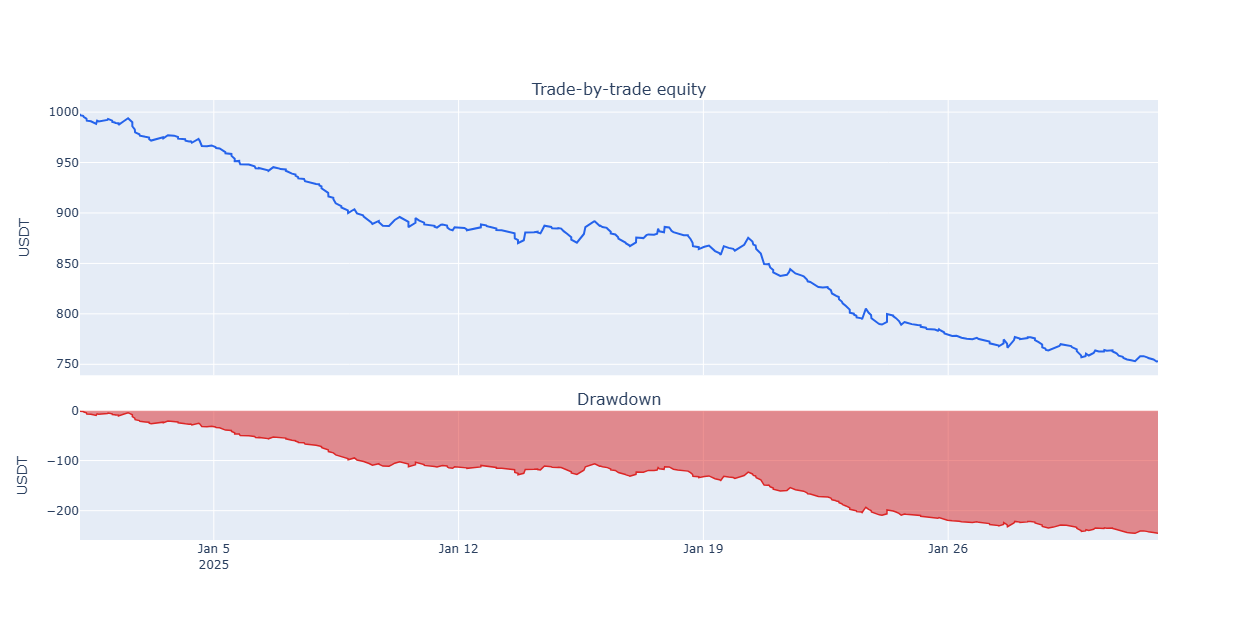

In [27]:
if equity_curve.empty:
    display(HTML("<p>No trades found, so no equity curve can be drawn.</p>"))
else:
    fig = make_subplots(
        rows=2,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.08,
        row_heights=[0.68, 0.32],
        subplot_titles=("Trade-by-trade equity", "Drawdown"),
    )
    fig.add_trace(
        go.Scatter(
            x=equity_curve["time"],
            y=equity_curve["equity"],
            mode="lines",
            name="Equity",
            line={"color": "#2563eb", "width": 2},
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=equity_curve["time"],
            y=-equity_curve["drawdown_abs"],
            mode="lines",
            fill="tozeroy",
            name="Drawdown",
            line={"color": "#dc2626", "width": 1.5},
        ),
        row=2,
        col=1,
    )
    fig.update_layout(height=620, hovermode="x unified", showlegend=False)
    fig.update_yaxes(title_text="USDT", row=1, col=1)
    fig.update_yaxes(title_text="USDT", row=2, col=1)
    fig.show()

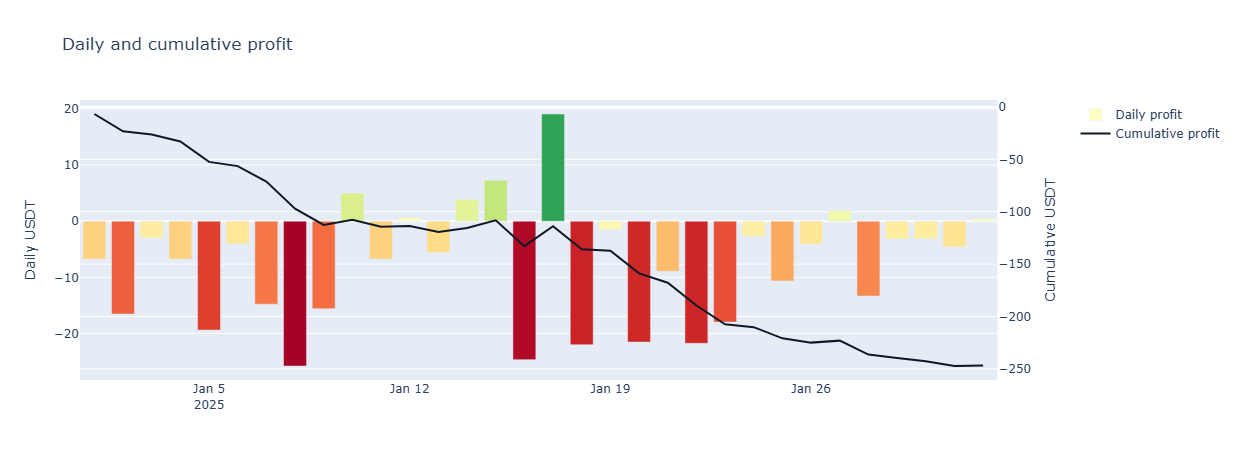

In [28]:
if daily_profit.empty:
    display(HTML("<p>No daily profit data found.</p>"))
else:
    fig = make_subplots(specs=[[{"secondary_y": True}]])
    fig.add_trace(
        go.Bar(
            x=daily_profit["date"],
            y=daily_profit["profit_abs"],
            name="Daily profit",
            marker={"color": daily_profit["profit_abs"], "colorscale": "RdYlGn", "cmid": 0},
        ),
        secondary_y=False,
    )
    fig.add_trace(
        go.Scatter(
            x=daily_profit["date"],
            y=daily_profit["cumulative_profit_abs"],
            name="Cumulative profit",
            line={"color": "#0f172a", "width": 2},
        ),
        secondary_y=True,
    )
    fig.update_layout(title="Daily and cumulative profit", height=460, hovermode="x unified")
    fig.update_yaxes(title_text="Daily USDT", secondary_y=False)
    fig.update_yaxes(title_text="Cumulative USDT", secondary_y=True)
    fig.show()

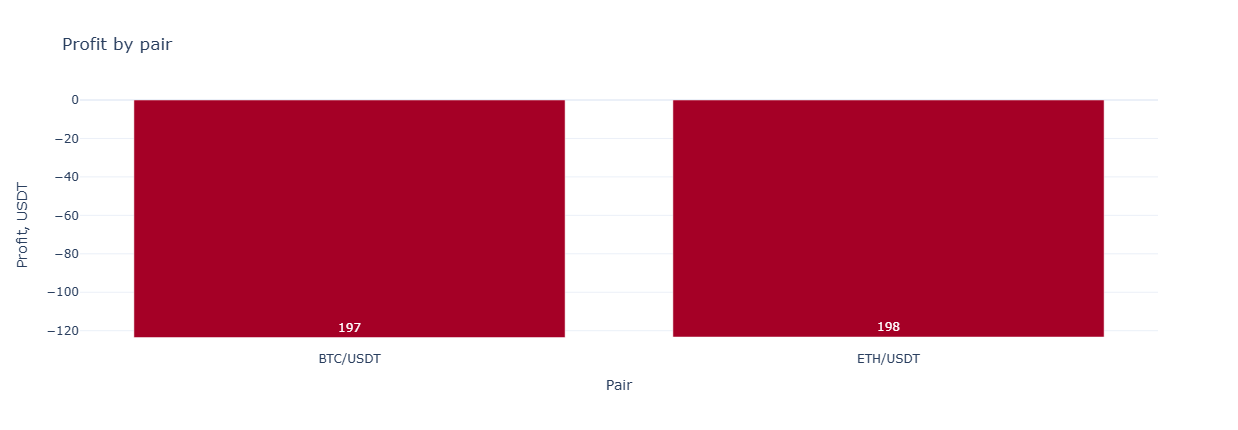

,pair,trades,profit_total_abs,profit_total,winrate,profit_factor,max_drawdown_abs
0,ETH/USDT,198,-123.29,-12.33%,23.23%,0.53,124.31
1,BTC/USDT,197,-123.54,-12.35%,21.32%,0.43,125.38
2,TOTAL,395,-246.83,-24.68%,22.28%,0.48,247.24


In [29]:
pair_rows = pair_summary.query("pair != 'TOTAL'") if not pair_summary.empty else pair_summary

if pair_rows.empty:
    display(HTML("<p>No pair summary found.</p>"))
else:
    fig = px.bar(
        pair_rows.sort_values("profit_total_abs"),
        x="pair",
        y="profit_total_abs",
        color="profit_total_abs",
        color_continuous_scale="RdYlGn",
        color_continuous_midpoint=0,
        text="trades",
        title="Profit by pair",
        labels={"profit_total_abs": "Profit, USDT", "pair": "Pair", "trades": "Trades"},
    )
    fig.update_layout(height=430, coloraxis_showscale=False)
    fig.show()

    display(
        pair_summary[
            ["pair", "trades", "profit_total_abs", "profit_total", "winrate", "profit_factor", "max_drawdown_abs"]
        ].style.format(
            {
                "profit_total_abs": "{:.2f}",
                "profit_total": "{:.2%}",
                "winrate": "{:.2%}",
                "profit_factor": "{:.2f}",
                "max_drawdown_abs": "{:.2f}",
            }
        )
    )

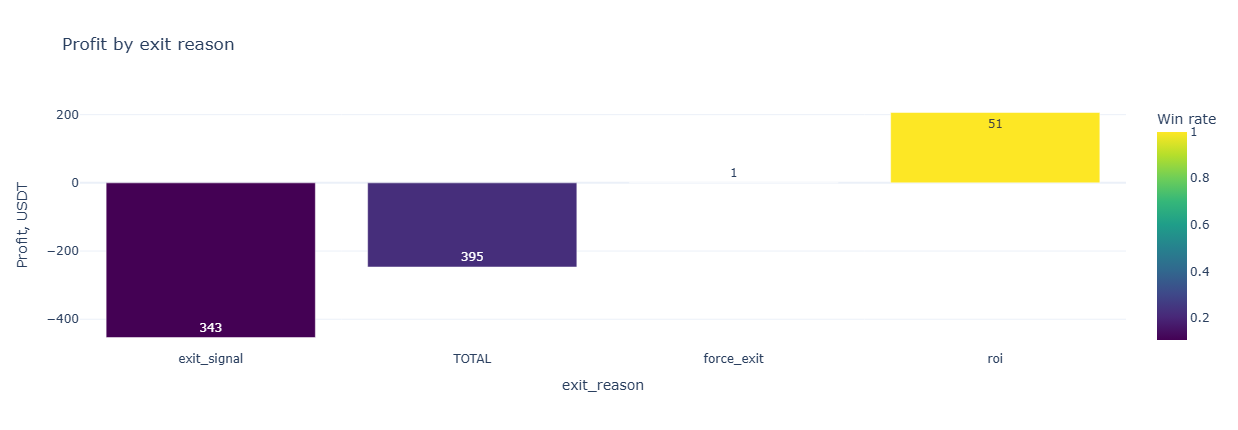

,exit_reason,trades,profit_total_abs,profit_total,winrate,profit_factor
0,roi,51,206.33,20.63%,100.00%,0.00
1,force_exit,1,0.41,0.04%,100.00%,0.00
2,exit_signal,343,-453.57,-45.36%,10.50%,0.05
3,TOTAL,395,-246.83,-24.68%,22.28%,0.48


In [30]:
if exit_summary.empty:
    display(HTML("<p>No exit reason summary found.</p>"))
else:
    fig = px.bar(
        exit_summary.sort_values("profit_total_abs"),
        x="exit_reason",
        y="profit_total_abs",
        color="winrate",
        text="trades",
        title="Profit by exit reason",
        color_continuous_scale="Viridis",
        labels={"profit_total_abs": "Profit, USDT", "winrate": "Win rate"},
    )
    fig.update_layout(height=430)
    fig.show()

    display(
        exit_summary[
            ["exit_reason", "trades", "profit_total_abs", "profit_total", "winrate", "profit_factor"]
        ].style.format(
            {
                "profit_total_abs": "{:.2f}",
                "profit_total": "{:.2%}",
                "winrate": "{:.2%}",
                "profit_factor": "{:.2f}",
            }
        )
    )

In [31]:
def profit_style(value: float) -> str:
    if pd.isna(value):
        return ""
    if value > 0:
        return "color: #047857; font-weight: 600;"
    if value < 0:
        return "color: #b91c1c; font-weight: 600;"
    return "color: #475569;"


trade_columns = [
    "pair",
    "open_date",
    "close_date",
    "open_rate",
    "close_rate",
    "profit_abs",
    "profit_ratio",
    "trade_duration",
    "exit_reason",
]
available_trade_columns = [column for column in trade_columns if column in trades]
recent_trades = trades[available_trade_columns].tail(30).copy()

display(
    recent_trades.style.format(
        {
            "open_rate": "{:.2f}",
            "close_rate": "{:.2f}",
            "profit_abs": "{:.2f}",
            "profit_ratio": "{:.2%}",
            "trade_duration": "{:.0f} min",
        }
    ).map(profit_style, subset=["profit_abs", "profit_ratio"])
)

,pair,open_date,close_date,open_rate,close_rate,profit_abs,profit_ratio,trade_duration,exit_reason
365,ETH/USDT,2025-01-29 15:50:00+00:00,2025-01-29 16:15:00+00:00,3106.50,3091.99,-1.68,-0.67%,25 min,exit_signal
366,ETH/USDT,2025-01-29 17:35:00+00:00,2025-01-29 19:10:00+00:00,3128.79,3082.50,-4.22,-1.68%,95 min,exit_signal
367,BTC/USDT,2025-01-29 17:15:00+00:00,2025-01-29 19:25:00+00:00,102285.00,101706.35,-1.93,-0.76%,130 min,exit_signal
368,BTC/USDT,2025-01-29 20:05:00+00:00,2025-01-29 22:15:00+00:00,102881.47,103534.58,1.08,0.43%,130 min,exit_signal
369,ETH/USDT,2025-01-29 20:20:00+00:00,2025-01-29 22:35:00+00:00,3120.90,3158.42,2.50,1.00%,135 min,roi
370,BTC/USDT,2025-01-29 23:35:00+00:00,2025-01-30 00:30:00+00:00,104072.34,103556.26,-1.74,-0.69%,55 min,exit_signal
371,ETH/USDT,2025-01-30 01:25:00+00:00,2025-01-30 03:50:00+00:00,3144.34,3182.14,2.51,1.00%,145 min,roi
372,BTC/USDT,2025-01-30 01:20:00+00:00,2025-01-30 04:55:00+00:00,104322.65,105576.82,2.51,1.00%,215 min,roi
373,ETH/USDT,2025-01-30 06:35:00+00:00,2025-01-30 07:25:00+00:00,3195.71,3189.75,-0.97,-0.39%,50 min,exit_signal
374,BTC/USDT,2025-01-30 08:45:00+00:00,2025-01-30 10:55:00+00:00,105136.27,105351.16,0.01,0.00%,130 min,exit_signal
